<a href="https://colab.research.google.com/github/AnuragKamblekar/Interncodes/blob/main/BasicAioperationonthebatteryandlocationdatasets23/4/2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

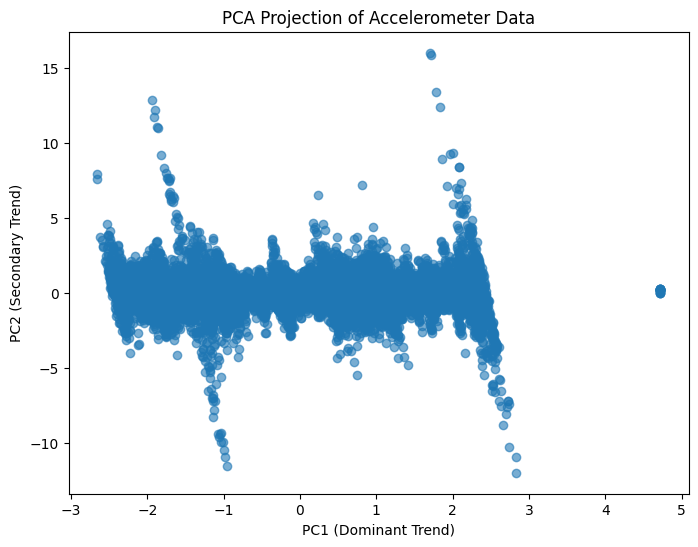

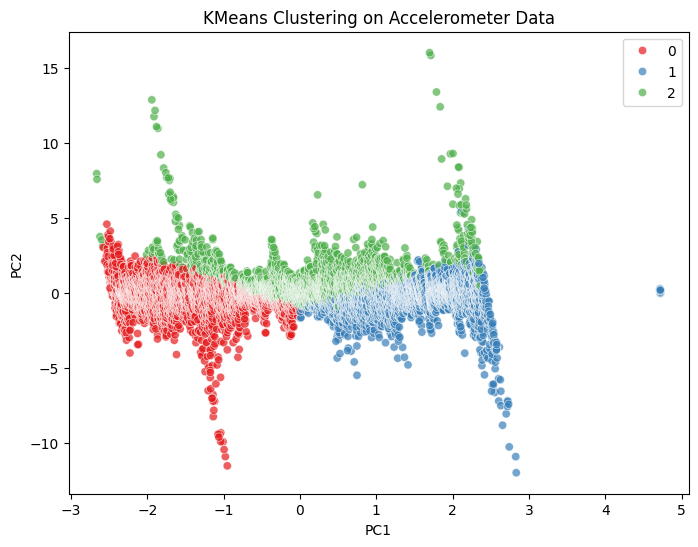

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Step 1: Load dataset
df = pd.read_csv("Accelerometer.csv")

# Rename accelerometer columns if present
df = df.rename(columns={'x':'AccX','y':'AccY','z':'AccZ'})

# Step 2: Select numeric features
numeric_df = df.apply(pd.to_numeric, errors='coerce')
X_clean = numeric_df.dropna()

if X_clean.empty:
    print("No numeric data available after cleaning.")
else:
    # Step 3: PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1 (Dominant Trend)")
    plt.ylabel("PC2 (Secondary Trend)")
    plt.title("PCA Projection of Accelerometer Data")
    plt.show()

    # Step 4: KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    df.loc[X_clean.index,'cluster'] = clusters

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clustering on Accelerometer Data")
    plt.show()

    # Step 5: Regression (if battery + location columns exist)
    if {'loc_speed','loc_altitude','battery_batteryLevel'}.issubset(df.columns):
        X_reg = df[['loc_speed','loc_altitude']].apply(pd.to_numeric, errors='coerce').dropna()
        y_reg = df.loc[X_reg.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')
        if not X_reg.empty and not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression()
            reg_model.fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            print("Regression MSE:", mse)

            plt.figure(figsize=(8,6))
            plt.scatter(y_test, y_pred, alpha=0.6)
            plt.xlabel("Actual Battery Level")
            plt.ylabel("Predicted Battery Level")
            plt.title("Regression: Actual vs Predicted Battery Level")
            plt.show()

    # Step 6: Classification (if lowPowerMode column exists)
    if 'battery_lowPowerMode' in df.columns:
        y_class = LabelEncoder().fit_transform(df['battery_lowPowerMode'].astype(str))
        if len(y_class) >= len(X_scaled):
            y_class = y_class[:len(X_scaled)]
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print("Classification Accuracy:", acc)

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title("Classification Confusion Matrix (Low Power Mode)")
        plt.show()


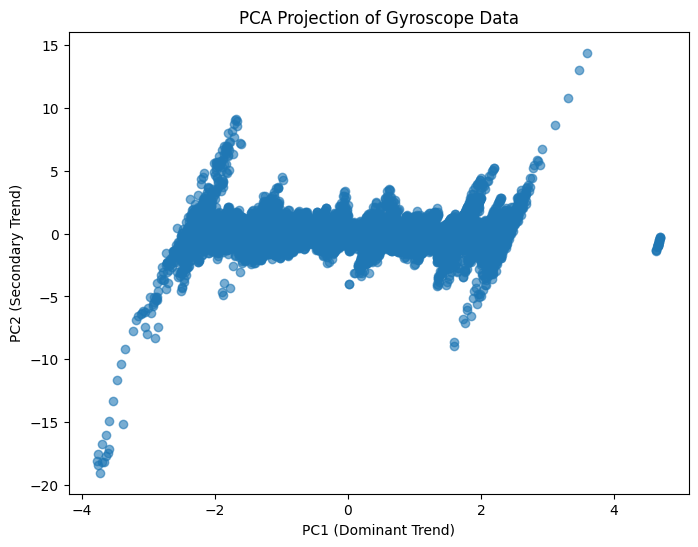

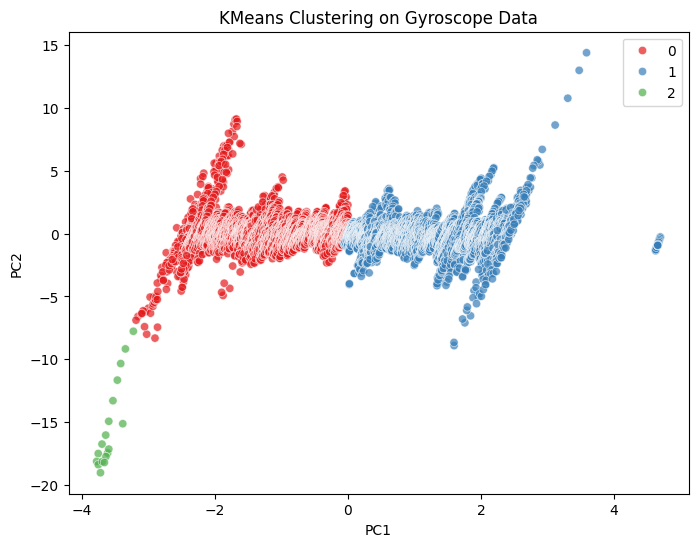

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Step 1: Load dataset
df = pd.read_csv("Gyroscope.csv")

# Rename gyroscope columns if present
df = df.rename(columns={'x':'GyroX','y':'GyroY','z':'GyroZ'})

# Step 2: Select numeric features
numeric_df = df.apply(pd.to_numeric, errors='coerce')
X_clean = numeric_df.dropna()

if X_clean.empty:
    print("No numeric data available after cleaning.")
else:
    # Step 3: PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1 (Dominant Trend)")
    plt.ylabel("PC2 (Secondary Trend)")
    plt.title("PCA Projection of Gyroscope Data")
    plt.show()

    # Step 4: KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    df.loc[X_clean.index,'cluster'] = clusters

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clustering on Gyroscope Data")
    plt.show()

    # Step 5: Regression (if battery + location columns exist)
    if {'loc_speed','loc_altitude','battery_batteryLevel'}.issubset(df.columns):
        X_reg = df[['loc_speed','loc_altitude']].apply(pd.to_numeric, errors='coerce').dropna()
        y_reg = df.loc[X_reg.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')
        if not X_reg.empty and not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression()
            reg_model.fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            print("Regression MSE:", mse)

            plt.figure(figsize=(8,6))
            plt.scatter(y_test, y_pred, alpha=0.6)
            plt.xlabel("Actual Battery Level")
            plt.ylabel("Predicted Battery Level")
            plt.title("Regression: Actual vs Predicted Battery Level")
            plt.show()

    # Step 6: Classification (if lowPowerMode column exists)
    if 'battery_lowPowerMode' in df.columns:
        y_class = LabelEncoder().fit_transform(df['battery_lowPowerMode'].astype(str))
        if len(y_class) >= len(X_scaled):
            y_class = y_class[:len(X_scaled)]
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print("Classification Accuracy:", acc)

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title("Classification Confusion Matrix (Low Power Mode)")
        plt.show()


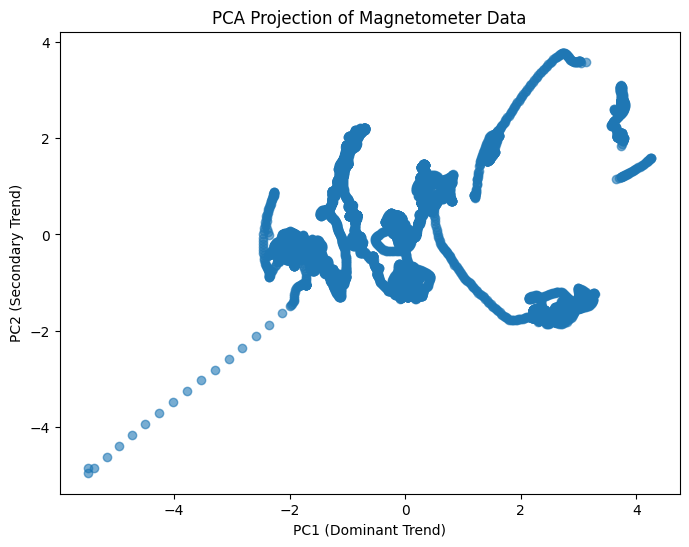

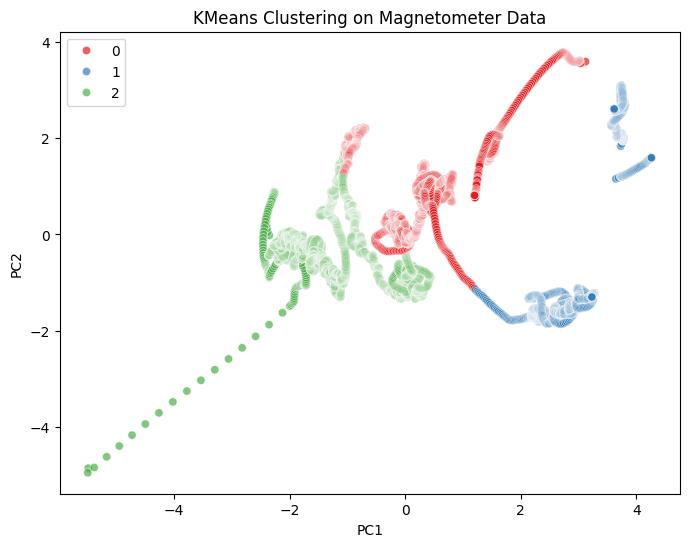

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Step 1: Load dataset
df = pd.read_csv("Magnetometer.csv")

# Rename magnetometer columns if present
df = df.rename(columns={'x':'MagX','y':'MagY','z':'MagZ'})

# Step 2: Select numeric features
numeric_df = df.apply(pd.to_numeric, errors='coerce')
X_clean = numeric_df.dropna()

if X_clean.empty:
    print("No numeric data available after cleaning.")
else:
    # Step 3: PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1 (Dominant Trend)")
    plt.ylabel("PC2 (Secondary Trend)")
    plt.title("PCA Projection of Magnetometer Data")
    plt.show()

    # Step 4: KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    df.loc[X_clean.index,'cluster'] = clusters

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clustering on Magnetometer Data")
    plt.show()

    # Step 5: Regression (if battery + location columns exist)
    if {'loc_speed','loc_altitude','battery_batteryLevel'}.issubset(df.columns):
        X_reg = df[['loc_speed','loc_altitude']].apply(pd.to_numeric, errors='coerce').dropna()
        y_reg = df.loc[X_reg.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')
        if not X_reg.empty and not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression()
            reg_model.fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            print("Regression MSE:", mse)

            plt.figure(figsize=(8,6))
            plt.scatter(y_test, y_pred, alpha=0.6)
            plt.xlabel("Actual Battery Level")
            plt.ylabel("Predicted Battery Level")
            plt.title("Regression: Actual vs Predicted Battery Level")
            plt.show()

    # Step 6: Classification (if lowPowerMode column exists)
    if 'battery_lowPowerMode' in df.columns:
        y_class = LabelEncoder().fit_transform(df['battery_lowPowerMode'].astype(str))
        if len(y_class) >= len(X_scaled):
            y_class = y_class[:len(X_scaled)]
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print("Classification Accuracy:", acc)

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title("Classification Confusion Matrix (Low Power Mode)")
        plt.show()


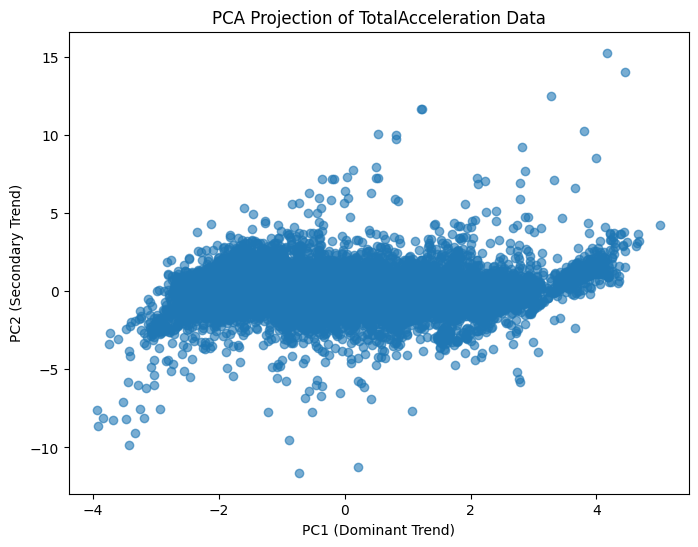

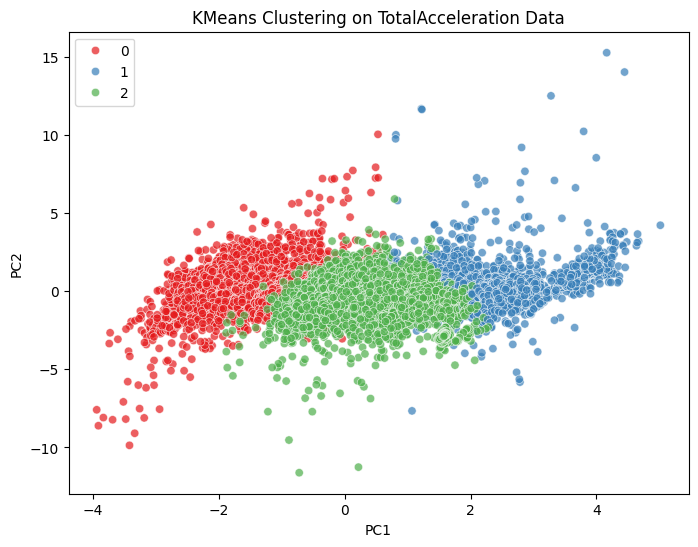

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Step 1: Load dataset
df = pd.read_csv("TotalAcceleration.csv")

# Rename total acceleration columns if present
df = df.rename(columns={'x':'TotalAccX','y':'TotalAccY','z':'TotalAccZ'})

# Step 2: Select numeric features
numeric_df = df.apply(pd.to_numeric, errors='coerce')
X_clean = numeric_df.dropna()

if X_clean.empty:
    print("No numeric data available after cleaning.")
else:
    # Step 3: PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1 (Dominant Trend)")
    plt.ylabel("PC2 (Secondary Trend)")
    plt.title("PCA Projection of TotalAcceleration Data")
    plt.show()

    # Step 4: KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    df.loc[X_clean.index,'cluster'] = clusters

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clustering on TotalAcceleration Data")
    plt.show()

    # Step 5: Regression (if battery + location columns exist)
    if {'loc_speed','loc_altitude','battery_batteryLevel'}.issubset(df.columns):
        X_reg = df[['loc_speed','loc_altitude']].apply(pd.to_numeric, errors='coerce').dropna()
        y_reg = df.loc[X_reg.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')
        if not X_reg.empty and not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression()
            reg_model.fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            print("Regression MSE:", mse)

            plt.figure(figsize=(8,6))
            plt.scatter(y_test, y_pred, alpha=0.6)
            plt.xlabel("Actual Battery Level")
            plt.ylabel("Predicted Battery Level")
            plt.title("Regression: Actual vs Predicted Battery Level")
            plt.show()

    # Step 6: Classification (if lowPowerMode column exists)
    if 'battery_lowPowerMode' in df.columns:
        y_class = LabelEncoder().fit_transform(df['battery_lowPowerMode'].astype(str))
        if len(y_class) >= len(X_scaled):
            y_class = y_class[:len(X_scaled)]
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print("Classification Accuracy:", acc)

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title("Classification Confusion Matrix (Low Power Mode)")
        plt.show()


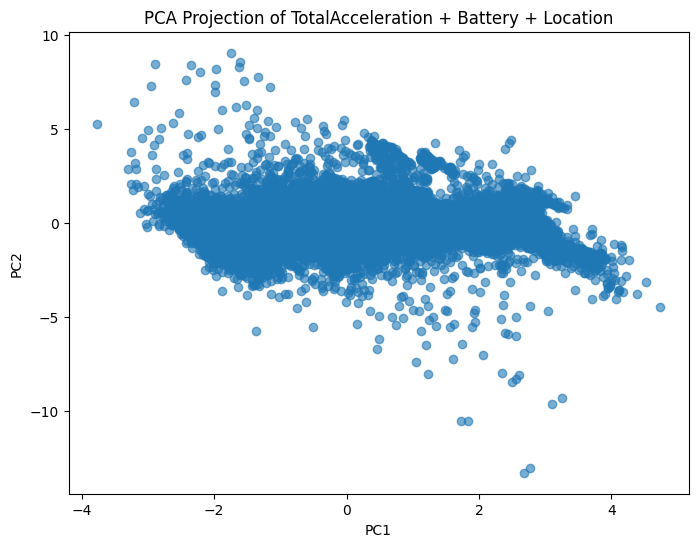

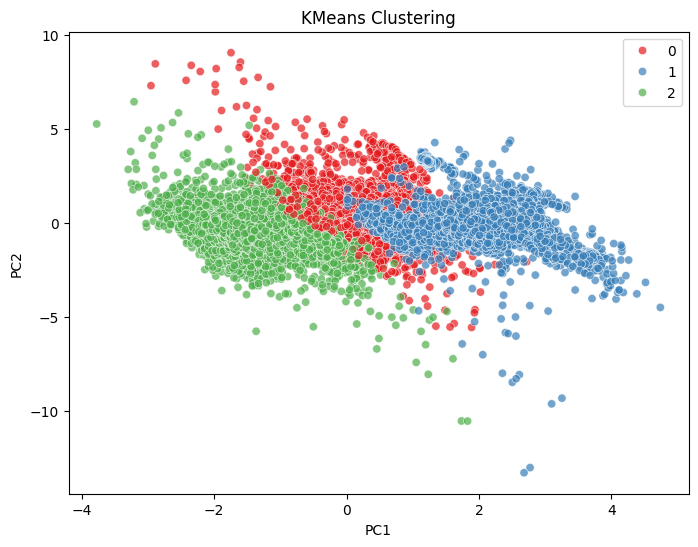

Regression MSE: 1.1539482493663454e-05


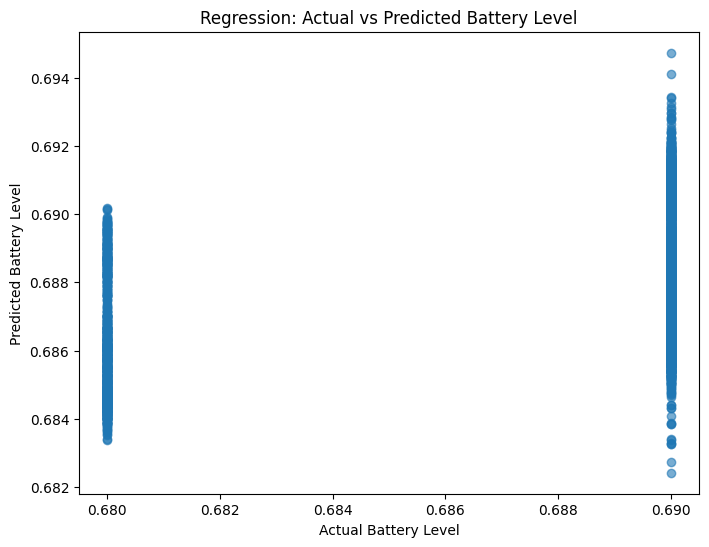

Classification skipped: only one class present in lowPowerMode.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Step 1: Load datasets
totacc_df = pd.read_csv("TotalAcceleration.csv")
battery_df = pd.read_csv("Battery.csv")
location_df = pd.read_csv("Location.csv")

# Rename TotalAcceleration columns
totacc_df = totacc_df.rename(columns={'x':'TotalAccX','y':'TotalAccY','z':'TotalAccZ'})

# Step 2: Merge datasets on seconds_elapsed
merged_df = pd.merge_asof(
    pd.merge_asof(
        totacc_df.sort_values("seconds_elapsed"),
        battery_df.sort_values("seconds_elapsed"),
        on="seconds_elapsed",
        direction="nearest"
    ),
    location_df.sort_values("seconds_elapsed"),
    on="seconds_elapsed",
    direction="nearest"
)

# Step 3: Select numeric features
features = ['TotalAccX','TotalAccY','TotalAccZ','batteryLevel','speed','altitude']
X = merged_df[features].apply(pd.to_numeric, errors='coerce').dropna()

# Step 4: PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of TotalAcceleration + Battery + Location")
plt.show()

# Step 5: KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
merged_df.loc[X.index,'cluster'] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering")
plt.show()

# Step 6: Regression (predict batteryLevel)
X_reg = merged_df[['TotalAccX','TotalAccY','TotalAccZ','speed','altitude']].apply(pd.to_numeric, errors='coerce').dropna()
y_reg = merged_df.loc[X_reg.index,'batteryLevel'].apply(pd.to_numeric, errors='coerce')
if not X_reg.empty and not y_reg.empty:
    X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
    reg_model = LinearRegression()
    reg_model.fit(X_train, y_train)
    y_pred = reg_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print("Regression MSE:", mse)

    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel("Actual Battery Level")
    plt.ylabel("Predicted Battery Level")
    plt.title("Regression: Actual vs Predicted Battery Level")
    plt.show()

# Step 7: Classification (predict lowPowerMode, only if >1 class exists)
if 'lowPowerMode' in merged_df.columns:
    y_class = LabelEncoder().fit_transform(merged_df['lowPowerMode'].astype(str))
    if len(np.unique(y_class)) > 1:  # Only run if at least 2 classes exist
        if len(y_class) >= len(X_scaled):
            y_class = y_class[:len(X_scaled)]
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print("Classification Accuracy:", acc)

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title("Classification Confusion Matrix (Low Power Mode)")
        plt.show()
    else:
        print("Classification skipped: only one class present in lowPowerMode.")
